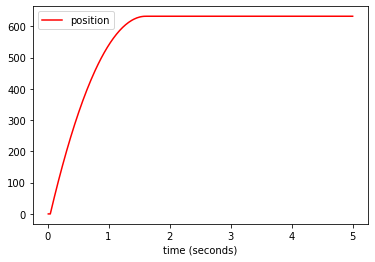

In [1]:
import arslabrobotics as ar

dp = ar.data.DataPlotter()
dp.set_x("time (seconds)")
dp.add_y("pos", "position")

dds = ar.dds.DDS()
dds.start()

dds.subscribe(['speed'])
dds.publish('force', 50000.0, ar.dds.DDS_TYPE_FLOAT)

t = ar.utils.Time()

integr = ar.system.Integrator()

t.start()
while t.get() < 5:
    
    v = dds.wait('speed')
    delta_t = t.elapsed()
    
    p = integr.evaluate(delta_t, v)
    
    dds.publish('force', 0.0, ar.dds.DDS_TYPE_FLOAT)
    
    dp.append_x(t.get())
    dp.append_y("pos", p)

dp.plot()
dds.stop()
